# Kapitel 4 Koduppgifter

### 11.

In [23]:
from sklearn.metrics import classification_report
y_true = [0, 1, 2, 2, 2]
y_pred = [0, 0, 2, 2, 1]
target_names = ['class 0', 'class 1', 'class 2']
print(classification_report(y_true, y_pred, target_names=target_names))


              precision    recall  f1-score   support

     class 0       0.50      1.00      0.67         1
     class 1       0.00      0.00      0.00         1
     class 2       1.00      0.67      0.80         3

    accuracy                           0.60         5
   macro avg       0.50      0.56      0.49         5
weighted avg       0.70      0.60      0.61         5



### 13.

In [24]:
import pandas as pd
from sklearn import set_config
set_config(display="text")

df = pd.read_excel("data/hr_employee_data.xlsx")
print(df.shape)
df.head()

(14999, 11)


,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


In [25]:
df = df.drop(columns=["Emp_Id"])
df["salary"] = df["salary"].map({"low": 0, "medium": 1, "high": 2})
df = pd.get_dummies(df, columns=["Department"], drop_first=True)

print(list(df.columns))

['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'salary', 'Department_RandD', 'Department_accounting', 'Department_hr', 'Department_management', 'Department_marketing', 'Department_product_mng', 'Department_sales', 'Department_support', 'Department_technical']


In [26]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["left"])
y = df["left"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print("train:", len(X_train), " val:", len(X_val), " test:", len(X_test))
print("Andel som slutat i träningsdatan:", round(y_train.mean(), 3))

train: 8999  val: 3000  test: 3000
Andel som slutat i träningsdatan: 0.238


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

print("Medelvärde i skalad träningsdata:", round(X_train_s.mean(), 6))

Medelvärde i skalad träningsdata: -0.0


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

modeller = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

for namn, m in modeller.items():
    m.fit(X_train_s, y_train)
    pred = m.predict(X_val_s)
    print(f"{namn:20s} acc: {accuracy_score(y_val, pred):.4f}  "
          f"precision: {precision_score(y_val, pred):.4f}  "
          f"recall: {recall_score(y_val, pred):.4f}  "
          f"f1: {f1_score(y_val, pred):.4f}")

LogisticRegression   acc: 0.7937  precision: 0.6067  recall: 0.3782  f1: 0.4659
DecisionTree         acc: 0.9767  precision: 0.9423  recall: 0.9608  f1: 0.9515
RandomForest         acc: 0.9913  precision: 0.9957  recall: 0.9678  f1: 0.9815
ExtraTrees           acc: 0.9863  precision: 0.9870  recall: 0.9552  f1: 0.9708


In [29]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {"n_estimators": [100, 200], "max_depth": [None, 10, 20], "min_samples_leaf": [1, 2]},
    cv=3, scoring="f1",
)
grid.fit(X_train_s, y_train)

print("Bästa hyperparametrar:", grid.best_params_)
print("Bästa f1 i korsvalideringen:", round(grid.best_score_, 4))

Bästa hyperparametrar: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Bästa f1 i korsvalideringen: 0.9709


In [30]:
from sklearn.metrics import classification_report, confusion_matrix

pred_val = grid.best_estimator_.predict(X_val_s)
print(classification_report(y_val, pred_val, target_names=["stannat", "slutat"]))

              precision    recall  f1-score   support

     stannat       0.99      1.00      0.99      2286
      slutat       1.00      0.97      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [31]:
X_train_full_s = scaler.fit_transform(X_train_full)
X_test_s = scaler.transform(X_test)

slutmodell = RandomForestClassifier(random_state=42, n_jobs=-1, **grid.best_params_)
slutmodell.fit(X_train_full_s, y_train_full)

pred_test = slutmodell.predict(X_test_s)
print(classification_report(y_test, pred_test, target_names=["stannat", "slutat"]))

              precision    recall  f1-score   support

     stannat       0.99      1.00      0.99      2286
      slutat       1.00      0.97      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [32]:
print(pd.DataFrame(confusion_matrix(y_test, pred_test),
                    index=["sant stannat", "sant slutat"],
                    columns=["pred stannat", "pred slutat"]))

              pred stannat  pred slutat
sant stannat          2283            3
sant slutat             24          690


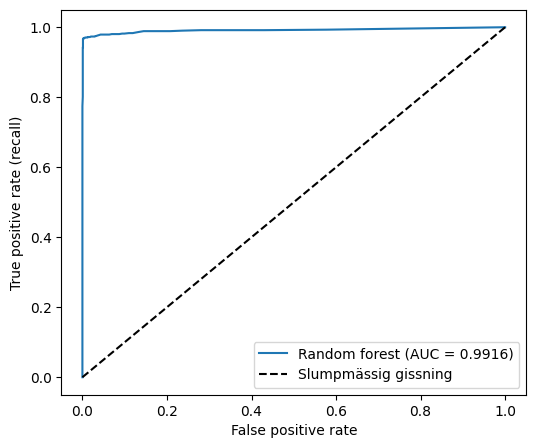

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

sannolikheter = slutmodell.predict_proba(X_test_s)[:, 1]
fpr, tpr, _ = roc_curve(y_test, sannolikheter)
auc = roc_auc_score(y_test, sannolikheter)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"Random forest (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", label="Slumpmässig gissning")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate (recall)")
ax.legend()
plt.show()

In [34]:
viktighet = pd.Series(slutmodell.feature_importances_, index=X.columns)
print(viktighet.sort_values(ascending=False).round(4).head(10))

satisfaction_level      0.3180
number_project          0.1846
time_spend_company      0.1812
average_montly_hours    0.1553
last_evaluation         0.1220
salary                  0.0116
Work_accident           0.0080
Department_technical    0.0037
Department_sales        0.0032
Department_support      0.0026
dtype: float64


### 15.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier

def display_confusion_matrix(y_true, y_pred):
  cm = confusion_matrix(y_true, y_pred)
  ConfusionMatrixDisplay(cm).plot()


(10000, 784)
(10000,)
True label for the plotted image is 5


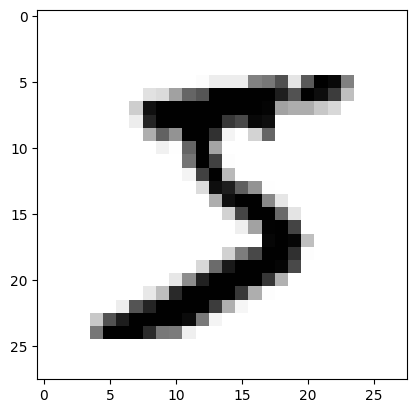

In [36]:
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X = mnist["data"][:10000]
y = mnist["target"][:10000].astype(np.uint8)
print(X.shape)
print(y.shape)

some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
print("True label for the plotted image is", y[0])

In [37]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [38]:
logreg_clf = LogisticRegression(max_iter=1000)

random_forest_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

extra_trees_clf = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42
)

named_estimators = [
    ("logreg_clf", logreg_clf),
    ("random_forest_clf", random_forest_clf),
    ("extra_trees_clf", extra_trees_clf)
]

voting_clf = VotingClassifier(
    named_estimators,
    voting='hard'
)

models = [
    logreg_clf,
    random_forest_clf,
    extra_trees_clf,
    voting_clf
]

for model in models:
    model.fit(X_train, y_train)

print("Accuracy for each model")

model_names = [
    "Logistic Regression",
    "Random Forest",
    "Extra Trees",
    "Voting Classifier"
]

for name, model in zip(model_names, models):
    score = model.score(X_val, y_val)
    print(f"{name:20s}: {score:.4f}")

Accuracy for each model
Logistic Regression : 0.8831
Random Forest       : 0.9375
Extra Trees         : 0.9456
Voting Classifier   : 0.9450


              precision    recall  f1-score   support

           0       0.97      0.99      0.98       176
           1       0.98      0.98      0.98       174
           2       0.93      0.90      0.91       148
           3       0.95      0.90      0.93       177
           4       0.95      0.93      0.94       167
           5       0.95      0.93      0.94       126
           6       0.95      0.97      0.96       161
           7       0.95      0.94      0.94       173
           8       0.92      0.95      0.94       142
           9       0.90      0.96      0.93       156

    accuracy                           0.95      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.95      0.95      0.95      1600



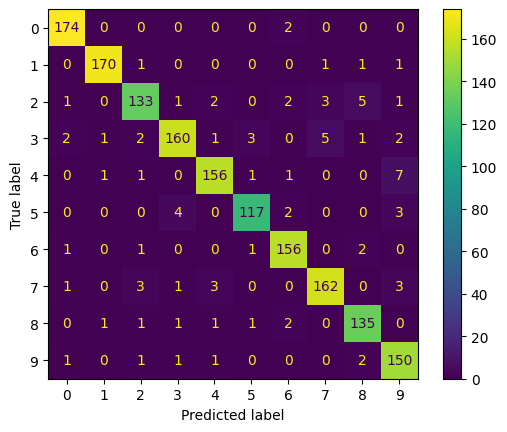

In [39]:
et_pred_val = extra_trees_clf.predict(X_val)

display_confusion_matrix(y_val, et_pred_val)
print(classification_report(y_val, et_pred_val))

In [40]:
X_train_val = scaler.fit_transform(X_train_val)
extra_trees_clf.fit(X_train_val, y_train_val)

et_pred_test = extra_trees_clf.predict(X_test)


In [41]:
scaler_2 = StandardScaler()
X = scaler_2.fit_transform(X)
extra_trees_clf.fit(X,y)

ExtraTreesClassifier(random_state=42)

In [42]:
from PIL import Image

In [43]:
def predict_digit(image_path, model):
    image = Image.open(image_path).convert("L")

    # MNIST har svart bakgrund och en ljus siffra
    image = np.array(image.resize((28, 28)), dtype=np.float32)
    if image.mean() > 127:
        image = 255 - image

    #debug code
    plt.imshow(image, cmap="gray")
    plt.axis("off")
    plt.show()

    # Centrera siffran och skala den till ungefär MNIST:s storlek
    foreground = image > 30
    if foreground.any():
        rows, columns = np.where(foreground)
        cropped = image[rows.min():rows.max() + 1, columns.min():columns.max() + 1]
        scale = min(20 / cropped.shape[0], 20 / cropped.shape[1])
        new_size = (
            max(1, round(cropped.shape[1] * scale)),
            max(1, round(cropped.shape[0] * scale)),
        )
        cropped = np.array(
            Image.fromarray(cropped.astype(np.uint8)).resize(new_size, Image.Resampling.LANCZOS),
            dtype=np.float32,
        )
        image = np.zeros((28, 28), dtype=np.float32)
        top = (28 - cropped.shape[0]) // 2
        left = (28 - cropped.shape[1]) // 2
        image[top:top + cropped.shape[0], left:left + cropped.shape[1]] = cropped

  


    # Visa bilden med samma ljus/mörker-konvention som MNIST
    plt.imshow(image, cmap="gray")
    plt.axis("off")
    plt.show()

    image = image.reshape(1, 784)
    image_scaled = scaler_2.transform(image)
    prediction = model.predict(image_scaled)

    print("Prediction:", prediction[0])
    return prediction[0]

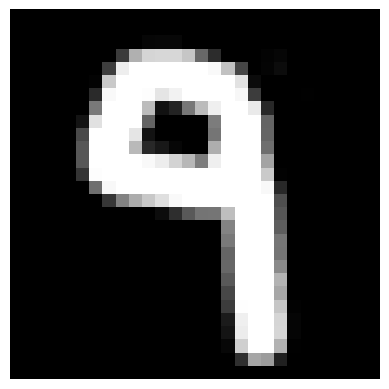

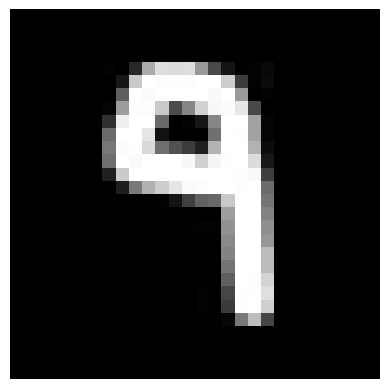

Prediction: 9


In [44]:
prediction = predict_digit("data/nine_2.png", extra_trees_clf)